 
# Exo-Planets Detection 

Hi we're SpaceNvaders a team driven by curiosity, powered by innovation, and united by a shared passion for exploring the unknown
With teamwork as our orbit and creativity as our fuel, we’re not just participants — we’re here to make an impact, to leave our mark among the stars 🌌

In [14]:

# Imports & configuration
import os
import json
import random
import logging
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')
from typing import Optional, List, Dict, Tuple
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import difflib
import lightgbm as lgb
import optuna
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    roc_auc_score, average_precision_score, confusion_matrix,
    classification_report, roc_curve, precision_recall_curve
)
from sklearn.feature_selection import VarianceThreshold
from sklearn.calibration import CalibratedClassifierCV
from imblearn.over_sampling import SMOTE
import re
import joblib
import shap
from pathlib import Path


In [15]:


# Configuration
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

DATA_PATH = r"c:\Users\XPS STORE\Downloads\cumulative_2025.10.01_14.22.26.csv"   # Change this to your dataset path
MODEL_DIR = r"d:\nasa_space_apps_kepler_splited\Final_Model"
os.makedirs(MODEL_DIR, exist_ok=True)

# Global target candidates that can be extended by user input
TARGET_CANDIDATES = [
    "planet disposition", "archive disposition", "koi_disposition",
    "disposition", "disposition_flag", "pl_disposition",
    "tfopwg_dispostion", "dispostion","tfopwg_disp"
]

logging.basicConfig(level=logging.INFO, format="%(asctime)s [%(levelname)s] %(message)s")




In [16]:
# Improved CSV loading function
def load_data(path):
    """More robust data loading with better error handling"""
    if path.endswith(".csv"):
        try:
            # First try standard read
            return pd.read_csv(path, comment="#", engine="python")
        except pd.errors.ParserError:
            try:
                # If that fails, try with on_bad_lines='skip' (newer pandas)
                return pd.read_csv(path, comment="#", engine="python", on_bad_lines='skip')
            except:
                # If that fails, try with error_bad_lines=False (older pandas)
                return pd.read_csv(path, comment="#", engine="python", error_bad_lines=False)
    elif path.endswith((".xls", ".xlsx")):
        # Excel loading
        raw = pd.read_excel(path, header=None, dtype=str)
        header_row = None
        for i, row in raw.iterrows():
            if row.dropna().str.contains(r"(pl_|koi_|st_)", case=False, regex=True).any():
                header_row = i
                break
        if header_row is None:
            raise ValueError("Could not detect a valid header row in Excel file")
        return pd.read_excel(path, skiprows=header_row)
    else:
        raise ValueError("Unsupported file type: " + path)

# Enhanced data preprocessing to handle datetime columns
def preprocess_dataframe(df):
    """Handle datetime columns and ensure all data is numeric for ML"""
    df_processed = df.copy()
    
    # Convert datetime columns to numeric features
    datetime_columns = []
    problematic_columns = []
    
    for col in df_processed.columns:
        # Skip if column is all null
        if df_processed[col].isna().all():
            problematic_columns.append(col)
            continue
            
        # Check if column contains datetime data - handle all datetime types
        if (df_processed[col].dtype == 'object' or 
            pd.api.types.is_datetime64_any_dtype(df_processed[col]) or
            'datetime' in str(df_processed[col].dtype).lower()):
            
            try:
                # Try to convert to datetime
                temp = pd.to_datetime(df_processed[col], errors='coerce')
                if not temp.isna().all():  # If successful conversion
                    datetime_columns.append(col)
                    # Extract useful features from datetime
                    df_processed[f'{col}_year'] = temp.dt.year.fillna(-1).astype(int)
                    df_processed[f'{col}_month'] = temp.dt.month.fillna(-1).astype(int)
                    df_processed[f'{col}_day'] = temp.dt.day.fillna(-1).astype(int)
                    df_processed[f'{col}_dayofweek'] = temp.dt.dayofweek.fillna(-1).astype(int)
                    # Drop original datetime column
                    df_processed = df_processed.drop(columns=[col])
            except Exception as e:
                print(f"Warning: Could not process datetime column {col}: {e}")
                problematic_columns.append(col)
    
    if datetime_columns:
        print(f"Converted datetime columns: {datetime_columns}")
    if problematic_columns:
        print(f"Dropping problematic columns: {problematic_columns}")
        df_processed = df_processed.drop(columns=problematic_columns, errors='ignore')
    
    return df_processed



In [17]:
# Web Interface Functions
def normalize_name(s: str) -> str:
    return re.sub(r'[^a-z0-9]', '', str(s).lower())

def find_column(df: pd.DataFrame, candidates: List[str]) -> Optional[str]:
    if df is None or df.columns.size == 0:
        return None

    cols = list(df.columns)
    lower_to_orig = {col.lower(): col for col in cols}
    norm_to_orig = {normalize_name(col): col for col in cols}

    # Prepare normalized candidate list
    cand_norms = [(cand, normalize_name(cand)) for cand in candidates]

    # 1) exact lowercase match
    for cand, cand_norm in cand_norms:
        if cand.lower() in lower_to_orig:
            return lower_to_orig[cand.lower()]

    # 2) normalized exact match
    for cand, cand_norm in cand_norms:
        if cand_norm in norm_to_orig and cand_norm != '':
            return norm_to_orig[cand_norm]

    # 3) normalized substring match
    for cand, cand_norm in cand_norms:
        if cand_norm == '':
            continue
        for norm_col, orig_col in norm_to_orig.items():
            if cand_norm in norm_col or norm_col in cand_norm:
                return orig_col

    # 4) token overlap (split on non-alnum)
    def tokens(x):
        return set(t for t in re.split(r'[^a-z0-9]+', x.lower()) if t)
    col_tokens = {col: tokens(col) for col in cols}
    for cand, _ in cand_norms:
        cand_tokens = tokens(cand)
        best_col, best_overlap = None, 0
        for col, tset in col_tokens.items():
            overlap = len(cand_tokens & tset)
            if overlap > best_overlap:
                best_overlap = overlap
                best_col = col
        if best_overlap >= 1:  # at least one token in common
            return best_col

    # 5) difflib close match on normalized names
    all_norms = list(norm_to_orig.keys())
    for cand, cand_norm in cand_norms:
        if cand_norm == '':
            continue
        matches = difflib.get_close_matches(cand_norm, all_norms, n=1, cutoff=0.8)
        if matches:
            return norm_to_orig[matches[0]]

    # not found
    return None

def detect_target(df: pd.DataFrame, target_candidates: List[str]) -> Optional[str]:
    # Try find_column first
    t = find_column(df, target_candidates)
    if t:
        return t
    for col in df.columns:
        low = col.lower()
        if any(k in low for k in ["dispos", "disposition", "status", "label"]):
            return col
    return None

def process_user_data(df: pd.DataFrame, user_target: Optional[str] = None) -> Dict:
    """
    Process user data from web interface.
    If target not found automatically, user can provide it.
    """
    global TARGET_CANDIDATES
    
    # Auto-detect target first
    target = detect_target(df, TARGET_CANDIDATES)
    
    # If not found and user provided target, use it and add to candidates
    if target is None and user_target:
        if user_target in df.columns:
            target = user_target
            # Add user's target to candidates for future use
            if user_target not in TARGET_CANDIDATES:
                TARGET_CANDIDATES.append(user_target)
                logging.info(f"Added user target '{user_target}' to target candidates")
        else:
            raise ValueError(f"User-provided target column '{user_target}' not found in dataset")
    
    # If still no target found, raise error
    if target is None:
        available_columns = list(df.columns)
        raise ValueError(f"No target column found. Available columns: {available_columns}. Please provide target column name.")
    
    return {
        "target": target,
        "available_columns": list(df.columns),
        "target_candidates": TARGET_CANDIDATES
    }



In [18]:

# Label cleaning function - MODIFIED: Remove FA and APC labels
def clean_labels(y: pd.Series) -> pd.Series:
    """
    Normalize labels for TOI/Kepler/TESS datasets.
    Returns cleaned labels and keeps original index.
    Removes FA and APC labels by setting them to NaN.
    """
    y_norm = (
        y.astype(str)
         .str.upper()
         .str.strip()
         .str.replace(r"[^A-Z]", "", regex=True)
    )

    label_mapping = {
        "PC": "CANDIDATE",
        "CP": "CONFIRMED",
        "KP": "CONFIRMED",
        "FP": "FALSE POSITIVE",
        "APC": None,  # Remove APC
        "FA": None,   # Remove FA
        "CANDIDATE": "CANDIDATE",
        "TOICANDIDATE": "CANDIDATE",
        "TCECANDIDATE": "CANDIDATE",
        "PLANETCANDIDATE": "CANDIDATE",
        "CONFIRMED": "CONFIRMED",
        "CONFIRMEDPLANET": "CONFIRMED",
        "PLANETCONFIRMED": "CONFIRMED",
        "FALSEPOSITIVE": "FALSE POSITIVE",
    }

    y_mapped = y_norm.map(label_mapping)

    # Fallback: if unknown, keep normalized label
    y_clean = y_mapped.where(y_mapped.notnull(), y_norm)
    
    # Additional filtering: remove any remaining FA or APC labels
    remove_labels = ['FA', 'APC']
    y_clean = y_clean.where(~y_clean.isin(remove_labels))

    logging.info(f"Labels after cleaning: {y_clean.value_counts().to_dict()}")
    return y_clean


# Updated feature groups with corrected radius ratio
def get_feature_groups():
    """Return the updated feature groups with proper radius ratio columns"""
    return {
        "planet_radius": ["pl_rade", "pl_radj", "pl_radii", "radius", "planet_diameter", "planet radius", "koi_prad", "rp", "planet_rad", "planet_radius"],
        "temperature": ["pl_eqt", "pl_eqt_err1", "pl_eqt_err2", "koi_teq", "eq_temp", "equilibrium_temperature", "planet_temperature", "temperature", "temp"],
        "stellar_temperature": ["st_teff", "koi_steff", "stellar_teff", "effective_temperature", "star_temp"],
        "distance": ["sy_dist", "st_dist", "distance", "distance_from_earth", "dist_from_earth", "dist", "d_planet", "star_distance", "sys_dist", "koi_dor"],
        "transit_duration": ["koi_duration", "pl_trandurh", "transit_duration"],
        "orbital_period": ["koi_period", "pl_orbper", "orbital_period", "period"],
        "stellar_radius": ["koi_srad", "st_rad", "stellar_radius"],
        "transit_depth": ["koi_depth", "pl_trandep", "transit_depth", "depth"],
        "star_planet_radius_ratio": ["koi_ror", "pl_ratror", "planet_to_star_radius_ratio", "ror", "radius_ratio", "pl_ratror"],
        "star_name":["tid","hostname","kepid","host","id"]
        
    }

def extract_confirmed_exoplanets(
    df: pd.DataFrame,
    target: Optional[str] = None,
    save_dir: str = "./output",
    name_candidates: Optional[List[str]] = None,
    feature_groups: Optional[Dict[str, List[str]]] = None,
) -> Tuple[pd.DataFrame, Dict]:
    
    if name_candidates is None:
        name_candidates = ["pl_name", "planet name", "kepoi_name", "kepoi", "name", "planet","toi"]

    # Use corrected feature groups
    if feature_groups is None:
        feature_groups = get_feature_groups()

    # detect target if not provided
    if target is None:
        logging.info("No target provided: attempting to auto-detect.")
        target = detect_target(df, TARGET_CANDIDATES)
        if target is None:
            raise ValueError("Target/disposition column not found. Please pass `target` explicitly.")

    if target not in df.columns:
        raise ValueError(f"Target column '{target}' not present in dataframe.")

    # normalize labels
    y_clean = clean_labels(df[target])
    
    # Filter both df and y_clean to keep only rows with valid labels
    valid_indices = y_clean.notna()
    df_filtered = df[valid_indices].copy()
    y_clean_filtered = y_clean[valid_indices]
    
    confirmed_mask = y_clean_filtered == "CONFIRMED"
    confirmed_df = df_filtered.loc[confirmed_mask].copy()

    if confirmed_df.empty:
        logging.warning("No confirmed exoplanets found after label normalization.")

    # planet name column
    planet_name_col = find_column(df_filtered, name_candidates)
    if planet_name_col is None:
        logging.warning("Planet name column not found automatically. Falling back to first column.")
        planet_name_col = df_filtered.columns[0]

    # search for each feature group
    found_features = {}
    for group_name, candidates in feature_groups.items():
        col = find_column(df_filtered, candidates)
        found_features[group_name] = col

    selected_cols = [planet_name_col, target] + [c for c in found_features.values() if c]
    selected_cols = [c for c in selected_cols if c in confirmed_df.columns]

    confirmed_info = confirmed_df[selected_cols].copy()

    # fill missing values
    for col in confirmed_info.columns:
        if confirmed_info[col].dtype.kind in "biufc":
            confirmed_info[col] = confirmed_info[col].fillna(confirmed_info[col].median())
        else:
            confirmed_info[col] = confirmed_info[col].fillna(confirmed_info[col].mode().iloc[0])

    os.makedirs(save_dir, exist_ok=True)
    csv_path = Path(save_dir) / "confirmed_exoplanets.csv"
    manifest_path = Path(save_dir) / "confirmed_exoplanets_manifest.json"

    confirmed_info.to_csv(csv_path, index=False)

    manifest = {
        "target_column_used": target,
        "planet_name_column": planet_name_col,
        "found_feature_columns": found_features,
        "saved_csv": str(csv_path.resolve()),
        "total_confirmed": len(confirmed_info)
    }

    with open(manifest_path, "w", encoding="utf-8") as f:
        json.dump(manifest, f, indent=2)

    logging.info(f"Saved {len(confirmed_info)} confirmed rows to {csv_path}")
    logging.info(f"Manifest saved to {manifest_path}")

    return confirmed_info, manifest

def extract_exoplanets_by_status(
    df: pd.DataFrame,
    status: str = "CONFIRMED",
    target: Optional[str] = None,
    save_dir: str = "./output"
) -> Tuple[pd.DataFrame, Dict]:
    """
    Extract exoplanets by specific status (CONFIRMED, CANDIDATE, FALSE POSITIVE)
    """
    valid_statuses = ["CONFIRMED", "CANDIDATE", "FALSE POSITIVE"]
    if status not in valid_statuses:
        raise ValueError(f"Status must be one of {valid_statuses}")
    
    # Process target detection
    target_info = process_user_data(df, target)
    target_col = target_info["target"]
    
    # Clean labels and filter
    y_clean = clean_labels(df[target_col])
    valid_indices = y_clean.notna()
    df_filtered = df[valid_indices].copy()
    y_clean_filtered = y_clean[valid_indices]
    
    status_mask = y_clean_filtered == status
    status_df = df_filtered.loc[status_mask].copy()
    
    if status_df.empty:
        logging.warning(f"No {status} exoplanets found after label normalization.")
    
    return status_df, target_info

# Updated web interface integration function
def handle_user_upload(file_path: str, user_target: Optional[str] = None, status: str = "CONFIRMED") -> Dict:
    """
    Main function to handle user upload from web interface with improved error handling
    """
    try:
        # Load user data with robust method
        df = load_data(file_path)
        
        logging.info(f"Loaded user dataset with {len(df)} rows and {len(df.columns)} columns")
        
        # Process data and detect target
        target_info = process_user_data(df, user_target)
        target = target_info["target"]
        
        logging.info(f"Using target column: {target}")
        
        # Extract exoplanets by status
        if status == "CONFIRMED":
            # Use the detailed extraction for confirmed planets
            extracted_info, manifest = extract_confirmed_exoplanets(
                df=df,
                target=target,
                save_dir="./user_output"
            )
        else:
            # Use simpler extraction for candidate/false positive
            extracted_info, target_info = extract_exoplanets_by_status(
                df=df,
                status=status,
                target=target,
                save_dir="./user_output"
            )
            manifest = {
                "target_column_used": target,
                "status_extracted": status,
                "total_count": len(extracted_info)
            }
        
        return {
            "success": True,
            "target": target,
            "status": status,
            "extracted_count": len(extracted_info),
            "manifest": manifest,
            "preview": extracted_info.head().to_dict('records'),
            "available_columns": target_info["available_columns"],
            "target_candidates": target_info["target_candidates"]
        }
        
    except Exception as e:
        logging.error(f"Error processing user data: {e}")
        try:
            # Try to get available columns with robust method
            df_test = load_data(file_path)
            available_cols = list(df_test.columns)
        except Exception as load_error:
            available_cols = [f"Unable to read columns: {str(load_error)}"]
            
        return {
            "success": False,
            "error": str(e),
            "available_columns": available_cols,
            "target_candidates": TARGET_CANDIDATES
        }


In [19]:

# Load the data
print("Loading dataset...")
df = load_data(DATA_PATH)
print(f"Dataset shape: {df.shape}")
print("\nFirst few rows:")
df.head()


# Detect and set target
target = detect_target(df, TARGET_CANDIDATES)

if target is None:
    raise ValueError("Could not detect a target column in dataset")

print(f"Using target column: {target}")

# Create X and y
y = df[target].copy()
X = df.drop(columns=[target], errors="ignore")

print("Unique raw labels before cleaning:", y.unique())
print("Counts per raw label:")
print(y.value_counts())


# Apply cleaning and filter data
y_clean = clean_labels(y)

# Filter both X and y to keep only rows with valid labels
valid_indices = y_clean.notna()
X = X[valid_indices]
y = y_clean[valid_indices]

print(f"After cleaning - X shape: {X.shape}, y shape: {y.shape}")
print("Labels after cleaning:")
print(y.value_counts())


# datetime handling
print("Preprocessing data and handling datetime columns...")
X_processed = preprocess_dataframe(X)

X = X_processed
print(f"Shape after datetime processing: {X.shape}")


# Data preprocessing - Drop irrelevant columns
drop_keywords = ['id','name','rowid','tic','ra','dec','kepid']
cols_to_drop = [c for c in X.columns if any(re.search(k, c, re.IGNORECASE) for k in drop_keywords)]
print(f"Auto drop columns (examples): {cols_to_drop[:10]}")
X = X.drop(columns=cols_to_drop, errors='ignore')


# Drop prior disposition columns
def drop_prior_disposition(df):
    kws = ['prior','previous','orig','initial','pre_disp','pdisposition','prev','solution']
    drops = [c for c in df.columns if any(k in c.lower() for k in kws)]
    if drops:
        print(f"Dropping prior-like columns: {drops}")
        return df.drop(columns=drops, errors='ignore')
    return df

X = drop_prior_disposition(X)



# Clean column names
def clean_cols(cols):
    out = []
    for c in cols:
        nc = re.sub(r'[^a-z0-9]+','_', c.lower()).strip('_')
        if nc == '': nc = 'col_unnamed'
        if re.match(r'^\d', nc): nc = 'col_'+nc
        out.append(nc)
    return out

X.columns = clean_cols(X.columns)
print(f"Columns after cleaning (sample): {list(X.columns[:20])}")



# Handle nulls and constant columns
null_threshold = 0.5
null_drops = [c for c in X.columns if X[c].isnull().mean() > null_threshold]
print(f"Dropping cols with >50% nulls: {len(null_drops)}")
X = X.drop(columns=null_drops, errors='ignore')

const_drops = [c for c in X.columns if X[c].nunique() <= 1]
print(f"Dropping constant cols: {len(const_drops)}")
X = X.drop(columns=const_drops, errors='ignore')



# Fill missing values
print("Filling missing values...")
for c in X.columns:
    if X[c].dtype == 'object':
        X[c] = X[c].fillna(X[c].mode().iloc[0] if not X[c].mode().empty else '')
    else:
        X[c] = X[c].fillna(X[c].median())


# Ensure all data is numeric - CRITICAL FIX FOR SMOTE
print("Ensuring all data is numeric...")
for col in X.columns:
    if X[col].dtype == 'object':
        # Try to convert to numeric, if fails then label encode
        try:
            X[col] = pd.to_numeric(X[col], errors='raise')
        except:
            le = LabelEncoder()
            X[col] = le.fit_transform(X[col].astype(str))
    # Handle any remaining non-numeric types
    elif not np.issubdtype(X[col].dtype, np.number):
        try:
            X[col] = X[col].astype(float)
        except:
            le = LabelEncoder()
            X[col] = le.fit_transform(X[col].astype(str))



# Winsorize numeric outliers
num_cols = X.select_dtypes(include=np.number).columns.tolist()

def winsorize(df, cols, factor=3.0):
    for c in cols:
        q1, q3 = df[c].quantile(0.25), df[c].quantile(0.75)
        iqr = q3 - q1
        if pd.isna(iqr) or iqr == 0:
            continue
        low, high = q1 - factor*iqr, q3 + factor*iqr
        df[c] = np.clip(df[c], low, high)
    return df

if len(num_cols) > 0:
    X[num_cols] = winsorize(X.copy(), num_cols)[num_cols]
    
print(f"Numeric cols sample: {num_cols[:10]}")



# Encode categoricals and scale numerics
cat_cols = X.select_dtypes(include='object').columns.tolist()
num_cols = X.select_dtypes(include=np.number).columns.tolist()

print(f"Categorical cols: {cat_cols}")
print(f"Numeric cols: {num_cols[:10]}")


# Label encode any remaining object columns
encoders = {}
for c in cat_cols:
    le = LabelEncoder()
    X[c] = le.fit_transform(X[c].astype(str))
    encoders[c] = le

# Scale numeric columns
scaler = StandardScaler()
if len(num_cols) > 0:
    X[num_cols] = scaler.fit_transform(X[num_cols])

print("Preprocessing completed!")
print(f"Final feature matrix shape: {X.shape}")
print(f"Final data types: {X.dtypes.value_counts()}")



Loading dataset...


2025-10-03 02:19:56,734 [INFO] Labels after cleaning: {'FALSE POSITIVE': 4839, 'CONFIRMED': 2746, 'CANDIDATE': 1979}


Dataset shape: (9564, 141)

First few rows:
Using target column: koi_disposition
Unique raw labels before cleaning: ['CONFIRMED' 'CANDIDATE' 'FALSE POSITIVE']
Counts per raw label:
koi_disposition
FALSE POSITIVE    4839
CONFIRMED         2746
CANDIDATE         1979
Name: count, dtype: int64
After cleaning - X shape: (9564, 140), y shape: (9564,)
Labels after cleaning:
koi_disposition
FALSE POSITIVE    4839
CONFIRMED         2746
CANDIDATE         1979
Name: count, dtype: int64
Preprocessing data and handling datetime columns...
Converted datetime columns: ['koi_vet_date']
Dropping problematic columns: ['koi_eccen_err1', 'koi_eccen_err2', 'koi_longp', 'koi_longp_err1', 'koi_longp_err2', 'koi_ingress', 'koi_ingress_err1', 'koi_ingress_err2', 'koi_sma_err1', 'koi_sma_err2', 'koi_incl_err1', 'koi_incl_err2', 'koi_teq_err1', 'koi_teq_err2', 'koi_model_dof', 'koi_model_chisq', 'koi_sage', 'koi_sage_err1', 'koi_sage_err2']
Shape after datetime processing: (9564, 124)
Auto drop columns (exampl

In [20]:

# Train-test split
print("Performing stratified random split...")
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_SEED, stratify=y
)

print(f"Before SMOTE - class distribution in train:")
print(y_train.value_counts())


# Apply SMOTE only to training set - WITH ERROR HANDLING
print("Applying SMOTE...")
try:
    # Final check to ensure all data is numeric
    for col in X_train.columns:
        if not np.issubdtype(X_train[col].dtype, np.number):
            X_train[col] = pd.to_numeric(X_train[col], errors='coerce').fillna(0)
    
    sm = SMOTE(random_state=RANDOM_SEED)
    X_train_res, y_train_res = sm.fit_resample(X_train, y_train)
    
    print(f"After SMOTE - class distribution in train_resampled:")
    print(pd.Series(y_train_res).value_counts())
    print(f"Train size: {X_train_res.shape}, Test size: {X_test.shape}")
    
except Exception as e:
    print(f"SMOTE failed: {e}")
    print("Using original training data without resampling...")
    X_train_res, y_train_res = X_train.copy(), y_train.copy()
    print("Proceeding with original imbalanced data")


# Feature list
features = X_train_res.columns.tolist()


# Fix for LightGBM multiclass error
print("Checking class distribution and fixing multiclass setup...")

# Check unique classes in the training data
unique_classes = pd.Series(y_train_res).unique()
print(f"Unique classes in training data: {unique_classes}")
print(f"Number of classes: {len(unique_classes)}")

# Ensure we have at least 2 classes for multiclass classification
if len(unique_classes) < 2:
    print(" Warning: Only one class found in training data. This might cause issues.")
    # If only one class, we'll need to handle this differently
    if len(unique_classes) == 1:
        print(f"Only one class found: {unique_classes[0]}")
        print("Consider checking your data preprocessing or target variable.")
else:
    print(" Multiple classes found - suitable for multiclass classification")
    

# Updated Optuna optimization with proper multiclass handling
n_trials = 10  # Reduced for testing

def objective(trial):
    # Get the actual number of classes
    num_classes = len(pd.Series(y_train_res).unique())
    
    param = {
        "objective": "multiclass",
        "num_class": num_classes,  # Explicitly set number of classes
        "boosting_type": "gbdt",
        "n_estimators": 500,  # Reduced for faster testing
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2),
        "num_leaves": trial.suggest_int("num_leaves", 20, 100),
        "max_depth": trial.suggest_int("max_depth", 3, 15),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 0.0, 1.0),
        "reg_lambda": trial.suggest_float("reg_lambda", 0.0, 1.0),
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 100),
        "force_col_wise": True,
        "random_state": RANDOM_SEED,
        "verbose": -1,
        "n_jobs": -1,
    }

    try:
        model = lgb.LGBMClassifier(**param)
        # Fit with validation set
        model.fit(
            X_train_res, y_train_res,
            eval_set=[(X_test, y_test)],
            eval_metric='multi_logloss',
            callbacks=[
                lgb.early_stopping(50, verbose=False),
                lgb.log_evaluation(0)
            ]
        )

        y_pred = model.predict(X_test)
        score = f1_score(y_test, y_pred, average="weighted")
        return score
    except Exception as e:
        print(f"Trial failed: {e}")
        return 0.0  # Return minimum score for failed trials

print("Running Optuna optimization with fixed multiclass setup...")
try:
    study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=RANDOM_SEED))
    study.optimize(objective, n_trials=n_trials)
    print(f" Best params: {study.best_trial.params}")
    print(f" Best F1 score: {study.best_trial.value:.4f}")
except Exception as e:
    print(f" Optuna optimization failed: {e}")
    print("Using default parameters...")
    best_params = {
        'learning_rate': 0.1,
        'num_leaves': 31,
        'max_depth': -1,
        'subsample': 0.8,
        'colsample_bytree': 0.8,
        'reg_alpha': 0.1,
        'reg_lambda': 0.1,
        'min_child_samples': 20
    }

# Train final model with proper error handling
print("Training final model with multiclass fix...")

if 'study' in locals() and hasattr(study, 'best_trial'):
    best_params = study.best_trial.params.copy()
else:
    # Use default parameters if optimization failed
    best_params = {
        'learning_rate': 0.1,
        'num_leaves': 31,
        'max_depth': -1,
        'subsample': 0.8,
        'colsample_bytree': 0.8,
        'reg_alpha': 0.1,
        'reg_lambda': 0.1,
        'min_child_samples': 20
    }

# Ensure required parameters are set
best_params.setdefault('n_estimators', 500)
best_params.setdefault('objective', 'multiclass')
best_params.setdefault('num_class', len(pd.Series(y_train_res).unique()))
best_params.setdefault('random_state', RANDOM_SEED)
best_params.setdefault('verbose', -1)
best_params.setdefault('n_jobs', -1)

try:
    clf = lgb.LGBMClassifier(**best_params)
    clf.fit(
        X_train_res, y_train_res,
        eval_set=[(X_test, y_test)],
        eval_metric='multi_logloss',
        callbacks=[lgb.early_stopping(50, verbose=False)]
    )
    print(" Model training completed successfully!")
except Exception as e:
    print(f" Model training failed: {e}")
    # Fallback: simple model without early stopping
    print("Trying fallback training...")
    clf = lgb.LGBMClassifier(
        n_estimators=100,
        random_state=RANDOM_SEED,
        verbose=-1,
        n_jobs=-1
    )
    clf.fit(X_train_res, y_train_res)
    print(" Fallback model training completed!")


# Optional calibration for binary
model_to_save = clf
calibrator = None
if best_params.get('objective') == 'binary':
    calibrator = CalibratedClassifierCV(clf, method='isotonic', cv='prefit')
    calibrator.fit(X_test, y_test)
    model_to_save = calibrator



Performing stratified random split...
Before SMOTE - class distribution in train:
koi_disposition
FALSE POSITIVE    3871
CONFIRMED         2197
CANDIDATE         1583
Name: count, dtype: int64
Applying SMOTE...


[I 2025-10-03 02:20:00,584] A new study created in memory with name: no-name-a5a8de11-48fa-401f-84b0-824c86ed80dc


After SMOTE - class distribution in train_resampled:
koi_disposition
FALSE POSITIVE    3871
CANDIDATE         3871
CONFIRMED         3871
Name: count, dtype: int64
Train size: (11613, 75), Test size: (1913, 75)
Checking class distribution and fixing multiclass setup...
Unique classes in training data: ['FALSE POSITIVE' 'CANDIDATE' 'CONFIRMED']
Number of classes: 3
 Multiple classes found - suitable for multiclass classification
Running Optuna optimization with fixed multiclass setup...


[I 2025-10-03 02:20:03,127] Trial 0 finished with value: 0.9400633247252195 and parameters: {'learning_rate': 0.08116262258099886, 'num_leaves': 97, 'max_depth': 12, 'subsample': 0.8394633936788146, 'colsample_bytree': 0.6624074561769746, 'reg_alpha': 0.15599452033620265, 'reg_lambda': 0.05808361216819946, 'min_child_samples': 88}. Best is trial 0 with value: 0.9400633247252195.
[I 2025-10-03 02:20:04,170] Trial 1 finished with value: 0.9406538225740436 and parameters: {'learning_rate': 0.12421185223120967, 'num_leaves': 77, 'max_depth': 3, 'subsample': 0.9879639408647978, 'colsample_bytree': 0.9329770563201687, 'reg_alpha': 0.21233911067827616, 'reg_lambda': 0.18182496720710062, 'min_child_samples': 22}. Best is trial 1 with value: 0.9406538225740436.
[I 2025-10-03 02:20:06,598] Trial 2 finished with value: 0.9364856697886234 and parameters: {'learning_rate': 0.06780602616231217, 'num_leaves': 62, 'max_depth': 8, 'subsample': 0.7164916560792167, 'colsample_bytree': 0.8447411578889518,

 Best params: {'learning_rate': 0.06337755684060234, 'num_leaves': 63, 'max_depth': 4, 'subsample': 0.9208787923016158, 'colsample_bytree': 0.6298202574719083, 'reg_alpha': 0.9868869366005173, 'reg_lambda': 0.7722447692966574, 'min_child_samples': 24}
 Best F1 score: 0.9432
Training final model with multiclass fix...
 Model training completed successfully!


In [21]:

# Save model and preprocessing artifacts
ts = datetime.utcnow().strftime('%Y%m%dT%H%M%SZ')
model_path = os.path.join(MODEL_DIR, f'exoplanet_model_{ts}.joblib')
preproc_path = os.path.join(MODEL_DIR, f'preproc_{ts}.joblib')
joblib.dump(model_to_save, model_path)
joblib.dump({'scaler': scaler, 'encoders': encoders, 'features': features}, preproc_path)

print(f"Saved model to {model_path}")
print(f"Saved preprocessing artifacts to {preproc_path}")



Saved model to d:\nasa_space_apps_kepler_splited\Final_Model\exoplanet_model_20251002T232037Z.joblib
Saved preprocessing artifacts to d:\nasa_space_apps_kepler_splited\Final_Model\preproc_20251002T232037Z.joblib


Evaluating model...
Accuracy: 0.943
Precision: 0.943
Recall: 0.943
F1: 0.943


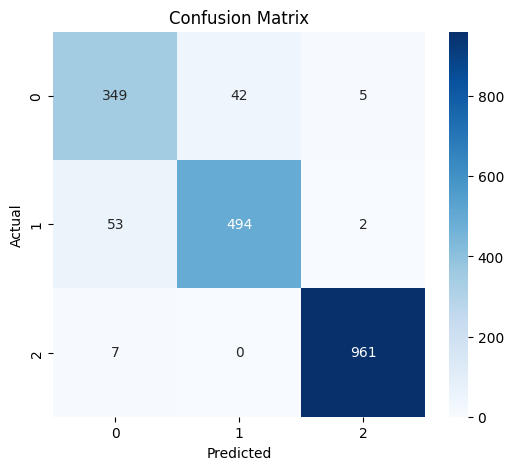


Classification Report:
                precision    recall  f1-score   support

     CANDIDATE       0.85      0.88      0.87       396
     CONFIRMED       0.92      0.90      0.91       549
FALSE POSITIVE       0.99      0.99      0.99       968

      accuracy                           0.94      1913
     macro avg       0.92      0.92      0.92      1913
  weighted avg       0.94      0.94      0.94      1913



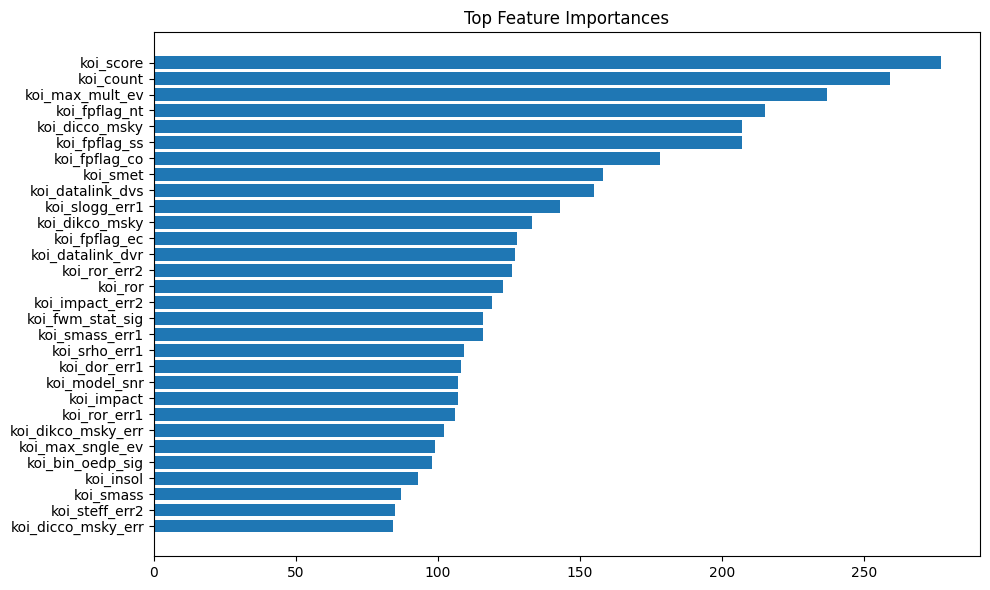

Generating SHAP explanations...


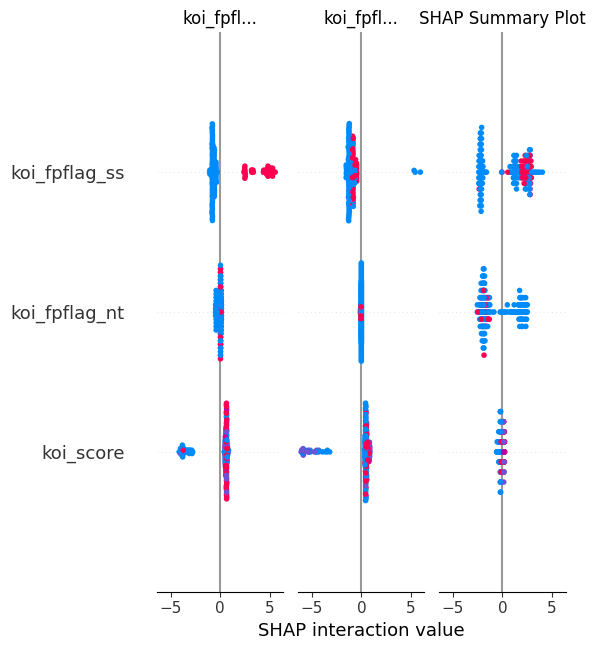

Generating Precision-Recall curve for CONFIRMED class...


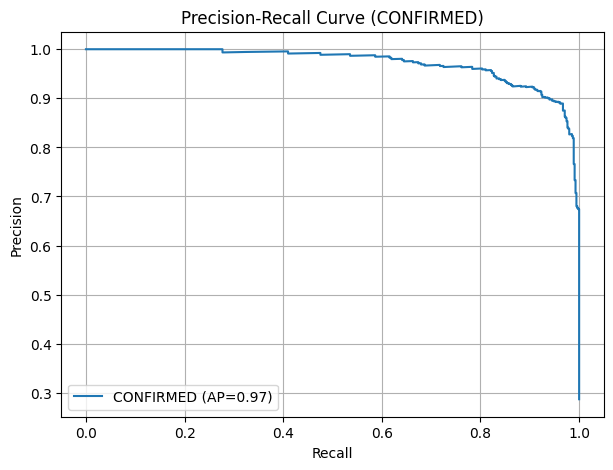

Manifest saved!


In [22]:

# Evaluation on test set
print("Evaluating model...")
if best_params.get('objective') == 'binary':
    y_proba = model_to_save.predict_proba(X_test)[:,1]
    y_pred = (y_proba>=0.5).astype(int)
else:
    y_proba = model_to_save.predict_proba(X_test)
    y_pred = model_to_save.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred):.3f}")
print(f"Precision: {precision_score(y_test, y_pred, average='weighted', zero_division=0):.3f}")
print(f"Recall: {recall_score(y_test, y_pred, average='weighted', zero_division=0):.3f}")
print(f"F1: {f1_score(y_test, y_pred, average='weighted', zero_division=0):.3f}")


# ROC  PR for binary
if best_params.get('objective') == 'binary':
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    plt.figure(figsize=(6,4))
    plt.plot(fpr,tpr)
    plt.title('ROC Curve')
    plt.xlabel('FPR')
    plt.ylabel('TPR')
    plt.grid(True)
    plt.show()
    
    precision, recall, _ = precision_recall_curve(y_test, y_proba)
    plt.figure(figsize=(6,4))
    plt.plot(recall, precision)
    plt.title('Precision-Recall Curve')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.grid(True)
    plt.show()


# Confusion matrix  classification report
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

print("\nClassification Report:")
print(classification_report(y_test, y_pred, zero_division=0))


# Feature importance
fi = clf.feature_importances_
idx = np.argsort(fi)[::-1][:30]
plt.figure(figsize=(10,6))
plt.barh(range(len(idx)), fi[idx][::-1])
plt.yticks(range(len(idx)), [features[i] for i in idx][::-1])
plt.title('Top Feature Importances')
plt.tight_layout()
plt.show()


# SHAP explainability
try:
    print("Generating SHAP explanations...")
    explainer = shap.TreeExplainer(clf)
    sample_idx = np.random.choice(len(X_test), size=min(200, len(X_test)), replace=False)
    sample = X_test.iloc[sample_idx]
    shap_values = explainer.shap_values(sample)
    
    # summary plot
    if isinstance(shap_values, list):
        shap.summary_plot(shap_values[0], sample, show=False)
    else:
        shap.summary_plot(shap_values, sample, show=False)
    plt.title('SHAP Summary Plot')
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f" SHAP failed: {e}")


# Precision-Recall Curve for CONFIRMED class
print("Generating Precision-Recall curve for CONFIRMED class...")

# Probabilities for all test data
y_proba = clf.predict_proba(X_test)

# Find index of CONFIRMED class
class_idx = list(clf.classes_).index("CONFIRMED")

# Binary labels: CONFIRMED vs not
y_true = (y_test == "CONFIRMED").astype(int)

# Extract probability for CONFIRMED
y_scores = y_proba[:, class_idx]

# Compute PR curve
precision, recall, thresholds = precision_recall_curve(y_true, y_scores)
ap = average_precision_score(y_true, y_scores)

# Plot
plt.figure(figsize=(7, 5))
plt.plot(recall, precision, label=f'CONFIRMED (AP={ap:.2f})')
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve (CONFIRMED)")
plt.legend()
plt.grid(True)
plt.show()


# Save manifest
manifest = {
    'model_path': model_path,
    'preproc_path': preproc_path,
    'timestamp': ts,
    'metrics': {
        'accuracy': float(accuracy_score(y_test, y_pred)),
        'f1': float(f1_score(y_test, y_pred, average='weighted'))
    }
}
manifest_path = os.path.join(MODEL_DIR, f'manifest_{ts}.json')
with open(manifest_path, 'w') as f:
    json.dump(manifest, f, indent=2)

print("Manifest saved!")


In [23]:


# Prediction helper function
def load_saved(model_path, preproc_path):
    model = joblib.load(model_path)
    pre = joblib.load(preproc_path)
    return model, pre

# Test prediction
model_loaded, pre_loaded = load_saved(model_path, preproc_path)

# Build a small example row from X_test
example_df = X_test.iloc[[0]][features]

# Predict
if best_params.get('objective') == 'binary':
    proba = model_loaded.predict_proba(example_df.values)[:, 1]
    pred = (proba >= 0.5).astype(int)
else:
    proba = model_loaded.predict_proba(example_df.values)
    pred = model_loaded.predict(example_df.values)

print(f"Example prediction: {pred}, probabilities: {proba}")


# Example usage of confirmed exoplanets extraction with UPDATED FEATURES
SAVE_DIR = r"./output"

print("Extracting confirmed exoplanets with updated features...")
confirmed_info, manifest = extract_confirmed_exoplanets(
    df,
    target=target,
    save_dir=SAVE_DIR,
)

print("Top rows of extracted table:")
print(confirmed_info.head().to_string(index=False))
print("\nManifest:")
print(json.dumps(manifest, indent=2))


# Test the corrected extraction
print("\n=== Testing Corrected Feature Extraction ===")
try:
    # Extract with corrected features
    confirmed_info_corrected, manifest_corrected = extract_confirmed_exoplanets(
        df,
        target=target,
        save_dir="./output_corrected"
    )
    
    print(" Corrected extraction successful!")
    print(f"Found {len(confirmed_info_corrected)} confirmed exoplanets")
    print("Corrected found features:")
    for feature_group, col_name in manifest_corrected['found_feature_columns'].items():
        if col_name:  # Only show found features
            print(f"  {feature_group}: {col_name}")
    
except Exception as e:
    print(f" Corrected extraction failed: {e}")



2025-10-03 02:20:39,099 [INFO] Labels after cleaning: {'FALSE POSITIVE': 4839, 'CONFIRMED': 2746, 'CANDIDATE': 1979}


Example prediction: ['FALSE POSITIVE'], probabilities: [[1.48816360e-03 2.89945755e-04 9.98221891e-01]]
Extracting confirmed exoplanets with updated features...


2025-10-03 02:20:39,199 [INFO] Saved 2746 confirmed rows to output\confirmed_exoplanets.csv
2025-10-03 02:20:39,200 [INFO] Manifest saved to output\confirmed_exoplanets_manifest.json
2025-10-03 02:20:39,227 [INFO] Labels after cleaning: {'FALSE POSITIVE': 4839, 'CONFIRMED': 2746, 'CANDIDATE': 1979}


Top rows of extracted table:
kepoi_name koi_disposition  koi_prad  koi_teq  koi_steff  koi_dor  koi_duration  koi_period  koi_srad  koi_depth  koi_ror    kepid
 K00752.01       CONFIRMED      2.26    793.0     5455.0    24.81        2.9575    9.488036     0.927      615.8 0.022344 10797460
 K00752.02       CONFIRMED      2.83    443.0     5455.0    77.90        4.5070   54.418383     0.927      874.8 0.027954 10797460
 K00755.01       CONFIRMED      2.75   1406.0     6031.0     8.75        1.6545    2.525592     1.046      603.3 0.024064 10854555
 K00756.01       CONFIRMED      3.90    835.0     6046.0    16.36        4.5945   11.094321     0.972     1517.5 0.036779 10872983
 K00756.02       CONFIRMED      2.77   1160.0     6046.0     6.96        3.1402    4.134435     0.972      686.0 0.026133 10872983

Manifest:
{
  "target_column_used": "koi_disposition",
  "planet_name_column": "kepoi_name",
  "found_feature_columns": {
    "planet_radius": "koi_prad",
    "temperature": "koi_teq",

2025-10-03 02:20:39,315 [INFO] Saved 2746 confirmed rows to output_corrected\confirmed_exoplanets.csv
2025-10-03 02:20:39,317 [INFO] Manifest saved to output_corrected\confirmed_exoplanets_manifest.json


 Corrected extraction successful!
Found 2746 confirmed exoplanets
Corrected found features:
  planet_radius: koi_prad
  temperature: koi_teq
  stellar_temperature: koi_steff
  distance: koi_dor
  transit_duration: koi_duration
  orbital_period: koi_period
  stellar_radius: koi_srad
  transit_depth: koi_depth
  star_planet_radius_ratio: koi_ror
  star_name: kepid


In [24]:

# Web interface simulation
print("\n=== Simulating Web Interface ===")
user_target = input("Enter target column name (or press Enter to use auto-detected): ").strip() or None
status_choice = input("Enter status to extract (CONFIRMED/CANDIDATE/FALSE POSITIVE) [CONFIRMED]: ").strip()
status_choice = status_choice if status_choice else "CONFIRMED"

try:
    result = handle_user_upload(DATA_PATH, user_target, status_choice)
    if result["success"]:
        print(f" Success! Found {result['extracted_count']} {result['status']} exoplanets")
        print(f" Target used: {result['target']}")
        print(f" Preview of first 3 rows:")
        for i, row in enumerate(result['preview'][:3]):
            print(f"   Row {i+1}: {row}")
        
        # Show found features
        if 'manifest' in result and 'found_feature_columns' in result['manifest']:
            print(f"🔍 Found features:")
            for feature_group, col_name in result['manifest']['found_feature_columns'].items():
                if col_name:
                    print(f"   - {feature_group}: {col_name}")
    else:
        print(f" Error: {result['error']}")
        print(" Available columns:", result['available_columns'])
        print(" Target candidates:", result['target_candidates'])
except Exception as e:
    print(f" Error: {e}")




=== Simulating Web Interface ===


2025-10-03 02:20:53,169 [INFO] Loaded user dataset with 9564 rows and 141 columns
2025-10-03 02:20:53,172 [INFO] Using target column: koi_disposition
2025-10-03 02:20:53,197 [INFO] Labels after cleaning: {'FALSE POSITIVE': 4839, 'CONFIRMED': 2746, 'CANDIDATE': 1979}
2025-10-03 02:20:53,267 [INFO] Saved 2746 confirmed rows to user_output\confirmed_exoplanets.csv
2025-10-03 02:20:53,268 [INFO] Manifest saved to user_output\confirmed_exoplanets_manifest.json


 Success! Found 2746 CONFIRMED exoplanets
 Target used: koi_disposition
 Preview of first 3 rows:
   Row 1: {'kepoi_name': 'K00752.01', 'koi_disposition': 'CONFIRMED', 'koi_prad': 2.26, 'koi_teq': 793.0, 'koi_steff': 5455.0, 'koi_dor': 24.81, 'koi_duration': 2.9575, 'koi_period': 9.48803557, 'koi_srad': 0.927, 'koi_depth': 615.8, 'koi_ror': 0.022344, 'kepid': 10797460}
   Row 2: {'kepoi_name': 'K00752.02', 'koi_disposition': 'CONFIRMED', 'koi_prad': 2.83, 'koi_teq': 443.0, 'koi_steff': 5455.0, 'koi_dor': 77.9, 'koi_duration': 4.507, 'koi_period': 54.4183827, 'koi_srad': 0.927, 'koi_depth': 874.8, 'koi_ror': 0.027954, 'kepid': 10797460}
   Row 3: {'kepoi_name': 'K00755.01', 'koi_disposition': 'CONFIRMED', 'koi_prad': 2.75, 'koi_teq': 1406.0, 'koi_steff': 6031.0, 'koi_dor': 8.75, 'koi_duration': 1.6545, 'koi_period': 2.525591777, 'koi_srad': 1.046, 'koi_depth': 603.3, 'koi_ror': 0.024064, 'kepid': 10854555}
🔍 Found features:
   - planet_radius: koi_prad
   - temperature: koi_teq
   - ste

In [25]:

# Summary of results
print("\n" + "="*60)
print(" SUMMARY OF RESULTS")
print("="*60)

# Calculate statistics
total_samples = len(df)
confirmed_count = len(y[y == 'CONFIRMED']) if 'y' in locals() else "N/A"
candidate_count = len(y[y == 'CANDIDATE']) if 'y' in locals() else "N/A"
false_positive_count = len(y[y == 'FALSE POSITIVE']) if 'y' in locals() else "N/A"

print(f"Dataset Statistics:")
print(f"Total samples: {total_samples}")
print(f"Confirmed exoplanets: {confirmed_count}")
print(f"Candidate exoplanets: {candidate_count}")
print(f"False Positives: {false_positive_count}")

# Model performance if available
if 'y_test' in locals() and 'y_pred' in locals():
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    
    print(f"\nModel Performance:")
    print(f"Accuracy: {accuracy:.3f}")
    print(f"F1 Score: {f1:.3f}")
    print(f"Precision: {precision:.3f}")
    print(f"Recall: {recall:.3f}")
else:
    print(f"\n Model Performance: Model not trained yet")





 SUMMARY OF RESULTS
Dataset Statistics:
Total samples: 9564
Confirmed exoplanets: 2746
Candidate exoplanets: 1979
False Positives: 4839

Model Performance:
Accuracy: 0.943
F1 Score: 0.943
Precision: 0.943
Recall: 0.943


In [26]:
# Show the exact file paths
print(f"📁 Save directory: {os.path.abspath(SAVE_DIR)}")
print(f"📄 CSV file saved at: {os.path.join(os.path.abspath(SAVE_DIR), 'confirmed_exoplanets.csv')}")
print(f"📋 Manifest file saved at: {os.path.join(os.path.abspath(SAVE_DIR), 'confirmed_exoplanets_manifest.json')}")

📁 Save directory: d:\nasa_space_apps_kepler_splited\output
📄 CSV file saved at: d:\nasa_space_apps_kepler_splited\output\confirmed_exoplanets.csv
📋 Manifest file saved at: d:\nasa_space_apps_kepler_splited\output\confirmed_exoplanets_manifest.json
